Library

Berhasil memuat gambar: tanaman_warnawarni.jpg
Ukuran gambar: 3475 x 2848 piksel


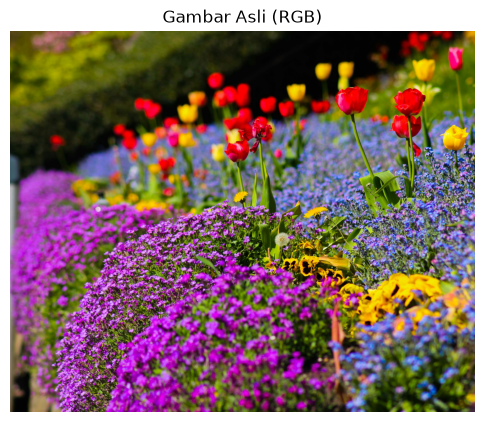

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- KONFIGURASI PATH ---
# Path Gambar Input (Menggunakan file yang kamu pilih)
IMAGE_PATH = r"D:\Semester 5\Data Citra\Kuliah-Data-Citra\Dataset\tanaman_warnawarni.jpg"

# Path Folder Output Hasil
OUTPUT_DIR = r"D:\Semester 5\Data Citra\Kuliah-Data-Citra\Tugas 2\Hasil"

# Buat folder Hasil jika belum ada
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Ambil nama file asli (misal: "tanaman_warnawarni.jpg")
filename = os.path.basename(IMAGE_PATH)

# Baca Gambar Input
img1 = cv2.imread(IMAGE_PATH)

if img1 is None:
    print(f"Gagal membaca gambar dari: {IMAGE_PATH}")
else:
    print(f"Berhasil memuat gambar: {filename}")
    print(f"Ukuran gambar: {img1.shape[1]} x {img1.shape[0]} piksel")

    # Tampilkan Gambar Asli (RGB)
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    plt.title("Gambar Asli (RGB)")
    plt.axis("off")
    plt.show()

## Transformasi RGB ke Grayscale

Selesai! Disimpan ke: D:\Semester 5\Data Citra\Kuliah-Data-Citra\Tugas 2\Hasil\Grayscale_tanaman_warnawarni.jpg


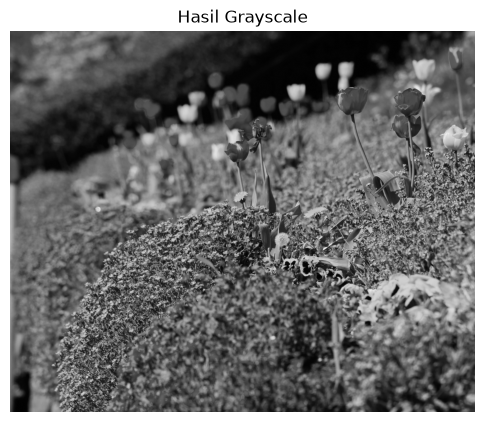

In [2]:
a, b, _ = img1.shape
img_gray = np.zeros((a, b), dtype=np.uint8)

# Proses Pixel-by-Pixel
for i in range(a):
    for j in range(b):
        B = int(img1[i, j, 0])
        G = int(img1[i, j, 1])
        R = int(img1[i, j, 2])

        # Bobot Luminance
        img_gray[i, j] = int(round(0.114 * B + 0.587 * G + 0.299 * R))

# Simpan Hasil
save_path_gray = os.path.join(OUTPUT_DIR, f"Grayscale_{filename}")
cv2.imwrite(save_path_gray, img_gray)
print(f"Selesai! Disimpan ke: {save_path_gray}")

# Plotting
plt.figure(figsize=(6, 6))
plt.imshow(img_gray, cmap="gray")
plt.title("Hasil Grayscale")
plt.axis("off")
plt.show()

## Transformasi RGB ke HSV

Selesai! Disimpan ke: D:\Semester 5\Data Citra\Kuliah-Data-Citra\Tugas 2\Hasil\HSV_tanaman_warnawarni.jpg


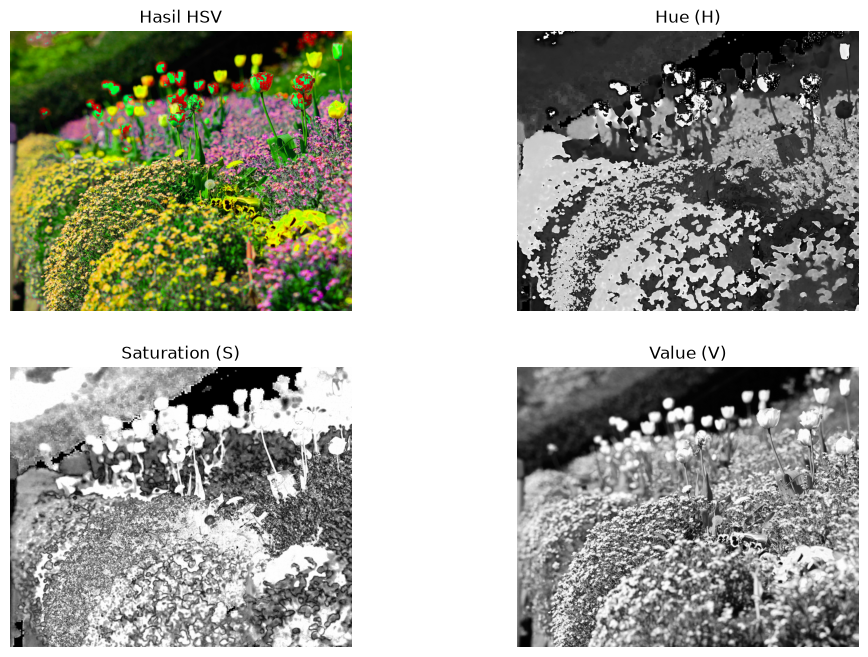

In [3]:
a, b, _ = img1.shape
img_hsv = np.zeros((a, b, 3), dtype=np.uint8)

# Proses Pixel-by-Pixel
for i in range(a):
    for j in range(b):
        B = int(img1[i, j, 0])
        G = int(img1[i, j, 1])
        R = int(img1[i, j, 2])

        Rn = R / 255.0
        Gn = G / 255.0
        Bn = B / 255.0

        maks = max(Rn, Gn, Bn)
        minimum = min(Rn, Gn, Bn)
        delta = maks - minimum

        # Value
        V = maks

        # Saturation
        S = 0 if maks == 0 else delta / maks

        # Hue
        if delta == 0:
            H = 0
        elif maks == Rn:
            H = 60 * (((Gn - Bn) / delta) % 6)
        elif maks == Gn:
            H = 60 * (((Bn - Rn) / delta) + 2)
        else:
            H = 60 * (((Rn - Gn) / delta) + 4)

        img_hsv[i, j, 0] = int(H / 360 * 255)
        img_hsv[i, j, 1] = int(S * 255)
        img_hsv[i, j, 2] = int(V * 255)

# Simpan Hasil
save_path_hsv = os.path.join(OUTPUT_DIR, f"HSV_{filename}")
cv2.imwrite(save_path_hsv, img_hsv)
print(f"Selesai! Disimpan ke: {save_path_hsv}")

# Display
H = img_hsv[:, :, 0]
S = img_hsv[:, :, 1]
V = img_hsv[:, :, 2]

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB))
plt.title("Hasil HSV")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(H, cmap="gray")
plt.title("Hue (H)")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(S, cmap="gray")
plt.title("Saturation (S)")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(V, cmap="gray")
plt.title("Value (V)")
plt.axis("off")

plt.show()

## Transformasi RGB ke YCbCr

Selesai! Disimpan ke: D:\Semester 5\Data Citra\Kuliah-Data-Citra\Tugas 2\Hasil\YCbCr_tanaman_warnawarni.jpg


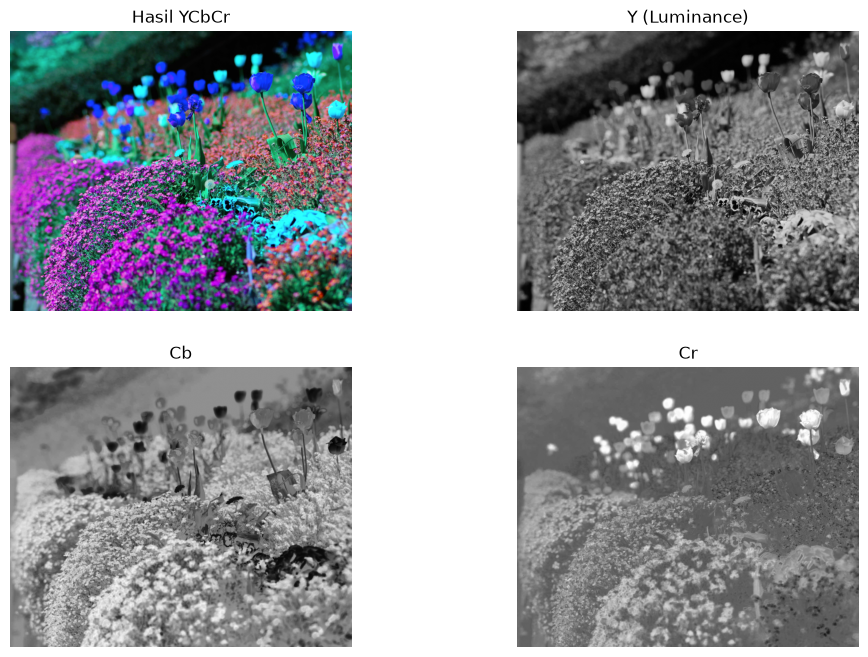

In [4]:
a, b, _ = img1.shape
img_ycbcr = np.zeros((a, b, 3), dtype=np.uint8)

# Proses Pixel-by-Pixel
for i in range(a):
    for j in range(b):
        B = int(img1[i, j, 0])
        G = int(img1[i, j, 1])
        R = int(img1[i, j, 2])

        Y = 0.299 * R + 0.587 * G + 0.114 * B
        Cb = -0.168736 * R - 0.331264 * G + 0.5 * B + 128
        Cr = 0.5 * R - 0.418688 * G - 0.081312 * B + 128

        img_ycbcr[i, j, 0] = np.clip(round(Y), 0, 255)
        img_ycbcr[i, j, 1] = np.clip(round(Cb), 0, 255)
        img_ycbcr[i, j, 2] = np.clip(round(Cr), 0, 255)

# Simpan Hasil
save_path_ycbcr = os.path.join(OUTPUT_DIR, f"YCbCr_{filename}")
cv2.imwrite(save_path_ycbcr, img_ycbcr)
print(f"Selesai! Disimpan ke: {save_path_ycbcr}")

# Display
Y = img_ycbcr[:, :, 0]
Cb = img_ycbcr[:, :, 1]
Cr = img_ycbcr[:, :, 2]

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(img_ycbcr, cv2.COLOR_YCrCb2RGB))
plt.title("Hasil YCbCr")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(Y, cmap="gray")
plt.title("Y (Luminance)")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(Cb, cmap="gray")
plt.title("Cb")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(Cr, cmap="gray")
plt.title("Cr")
plt.axis("off")

plt.show()

## Tranformasi RGB ke CMY

Selesai! Disimpan ke: D:\Semester 5\Data Citra\Kuliah-Data-Citra\Tugas 2\Hasil\CMY_tanaman_warnawarni.jpg


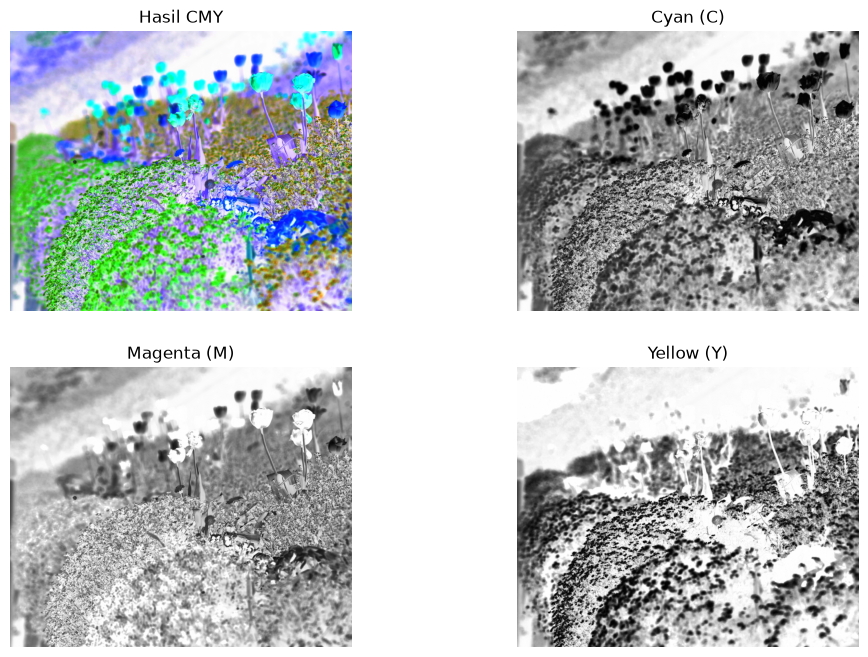

In [5]:
a, b, _ = img1.shape
img_cmy = np.zeros((a, b, 3), dtype=np.uint8)

# Proses Pixel-by-Pixel
for i in range(a):
    for j in range(b):
        B = int(img1[i, j, 0])
        G = int(img1[i, j, 1])
        R = int(img1[i, j, 2])

        Rn = R / 255.0
        Gn = G / 255.0
        Bn = B / 255.0

        C = 1 - Rn
        M = 1 - Gn
        Y = 1 - Bn

        img_cmy[i, j, 0] = int(round(C * 255))
        img_cmy[i, j, 1] = int(round(M * 255))
        img_cmy[i, j, 2] = int(round(Y * 255))

# Simpan Hasil
save_path_cmy = os.path.join(OUTPUT_DIR, f"CMY_{filename}")
cv2.imwrite(save_path_cmy, img_cmy)
print(f"Selesai! Disimpan ke: {save_path_cmy}")

# Display
C = img_cmy[:, :, 0]
M = img_cmy[:, :, 1]
Y = img_cmy[:, :, 2]

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img_cmy)
plt.title("Hasil CMY")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(C, cmap="gray")
plt.title("Cyan (C)")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(M, cmap="gray")
plt.title("Magenta (M)")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(Y, cmap="gray")
plt.title("Yellow (Y)")
plt.axis("off")

plt.show()